# Sandbox

## Experiment with OHLC data

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from eccore.ipython import nb_setup, pandas_nrows_ncols

nb_setup()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Set autoreload mode


In [7]:
p2data = Path('../data')
assert p2data.is_dir()

p2sp500 = p2data / 'raw-data/axitrader-new/US5001440.csv'
assert p2sp500.is_file()

AssertionError: 

In [97]:
df = pd.read_csv(p2sp500, header=None, parse_dates=[[0,1]], index_col=0)
df.columns = 'o h l c v'.split()
df.index.name = 'dt'
display(df.head())
df.info()

,o,h,l,c,v
dt,,,,,
2018-10-22,2759.02,2779.27,2747.27,2754.48,26562
2018-10-23,2753.11,2755.36,2690.69,2743.45,38777
2018-10-24,2744.83,2748.58,2651.23,2672.80,41777
2018-10-25,2670.80,2722.90,2657.93,2680.71,39034
2018-10-26,2675.59,2692.34,2627.59,2663.57,61436


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1590 entries, 2018-10-22 to 2024-12-13
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   o       1590 non-null   float64
 1   h       1590 non-null   float64
 2   l       1590 non-null   float64
 3   c       1590 non-null   float64
 4   v       1590 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 74.5 KB


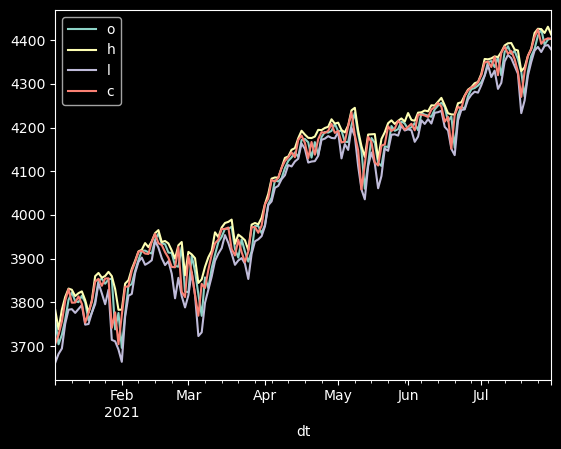

In [111]:
df.loc['2021-01-01':'2021-07-31','o h l c'.split(' ')].plot();

In [99]:
df['r'] = df['c'].pct_change()

list_ma_windows = [5,20,60]
for n in list_ma_windows:
    df[f"c-ma-{n:02d}"] = df.c.rolling(n).mean()
    df[f"r-ma-{n:02d}"] = df.r.rolling(n).mean()
    df[f"r-std-{n:02d}"] = df.r.rolling(n).std()
    

coi = "o h l c v".split(' ')
coi += [f"c-ma-{n:02d}" for n in list_ma_windows]
coi += ['r']
coi += [f"r-ma-{n:02d}" for n in list_ma_windows]
coi += [f"r-std-{n:02d}" for n in list_ma_windows]

df.loc[:, coi].tail()

,o,h,l,c,v,c-ma-05,c-ma-20,c-ma-60,r,r-ma-05,r-ma-20,r-ma-60,r-std-05,r-std-20,r-std-60
dt,,,,,,,,,,,,,,,
2024-12-09,6081.70,6090.75,6045.30,6049.05,43864,6065.87,5992.2615,5854.629000,-0.005140,0.000150,0.000405,0.001224,0.003772,0.004703,0.006604
2024-12-10,6050.70,6061.50,6026.00,6038.50,38201,6063.57,5994.9515,5861.349000,-0.001744,-0.000375,0.000458,0.001174,0.003828,0.004670,0.006615
2024-12-11,6040.45,6089.40,6032.68,6074.25,33363,6062.44,5999.1615,5868.853167,0.005920,-0.000179,0.000709,0.001306,0.004176,0.004828,0.006630
2024-12-12,6074.65,6076.00,6043.95,6046.65,46454,6057.75,6004.2475,5874.453500,-0.004544,-0.000765,0.000859,0.000974,0.004611,0.004600,0.006407
2024-12-13,6055.20,6059.60,6049.65,6051.65,3314,6052.02,6013.2650,5880.364333,0.000827,-0.000936,0.001519,0.001027,0.004513,0.003387,0.006392


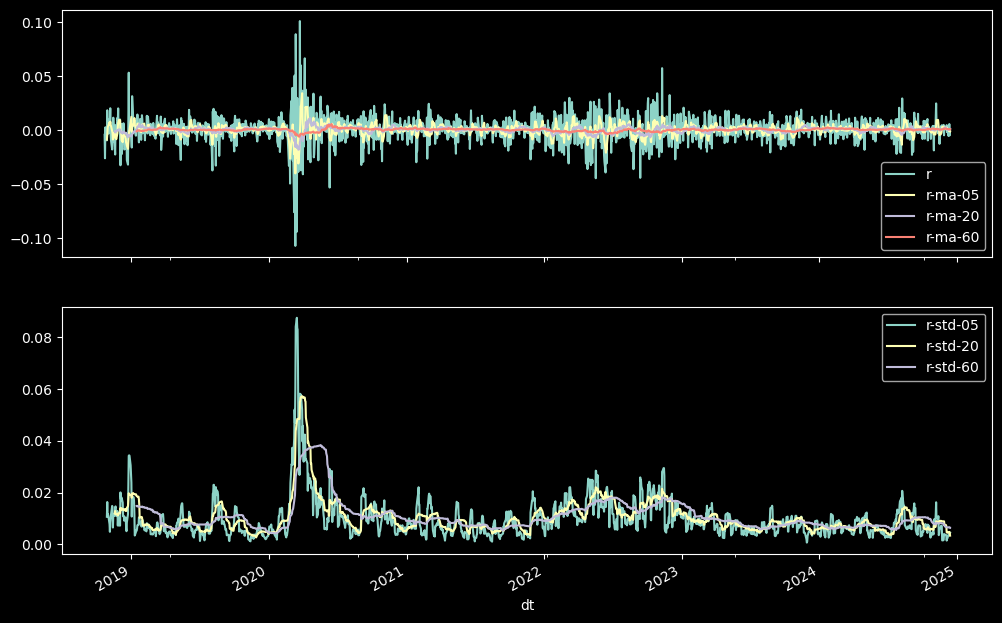

In [100]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(12,8), sharex=True)
df.loc[:,'r r-ma-05 r-ma-20 r-ma-60'.split(' ')].plot(ax=ax1);
df.loc[:,'r-std-05 r-std-20 r-std-60'.split(' ')].plot(ax=ax2);

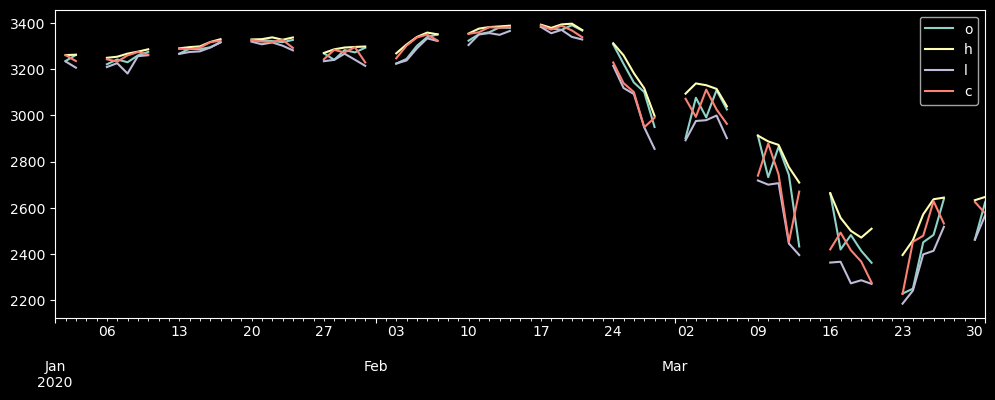

In [101]:
date_range = pd.date_range(start='2020-01-01', end='2020-03-31')

df.reindex(date_range).loc[:, 'o h l c'.split(' ')].plot(figsize=(12,4));

Add columns with Last Low and Last High (LL, LH) to the dataset:
- LL is the lowest low since the last high
- LH is the highest high since the last low

Run over each row of the dataset

In [102]:
df['HH'] = np.nan
df['LL'] = np.nan
df['Trend'] = np.nan

In [103]:
idx_0, idx_1 = df.index[0], df.index[1]
df.loc[idx_0, 'HH'] = df.loc[idx_0, 'h']
df.loc[idx_0, 'LL'] = df.loc[idx_0, 'l']
df.loc[idx_1, 'Trend'] = 'Up' if pd.to_numeric(df.loc[idx_1, 'r'], errors='coerce') >= 0 else 'Down'
df.head()

,o,h,l,c,v,r,c-ma-05,r-ma-05,r-std-05,c-ma-20,r-ma-20,r-std-20,c-ma-60,r-ma-60,r-std-60,HH,LL,Trend
dt,,,,,,,,,,,,,,,,,,
2018-10-22,2759.02,2779.27,2747.27,2754.48,26562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2779.27,2747.27,NaN
2018-10-23,2753.11,2755.36,2690.69,2743.45,38777,-0.004004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Down
2018-10-24,2744.83,2748.58,2651.23,2672.80,41777,-0.025752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-10-25,2670.80,2722.90,2657.93,2680.71,39034,0.002959,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-10-26,2675.59,2692.34,2627.59,2663.57,61436,-0.006394,2703.002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Ramer–Douglas–Peucker Algorithm

In [106]:
from crdp import rdp

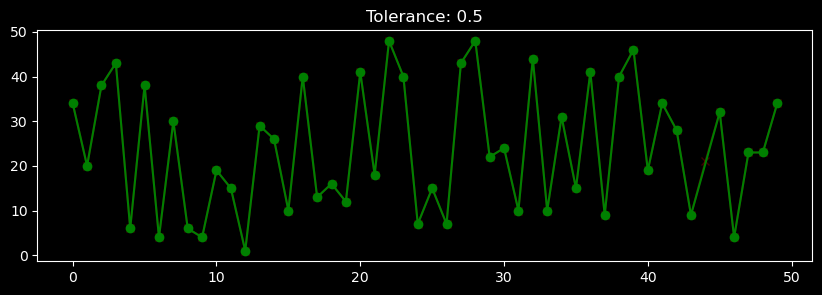

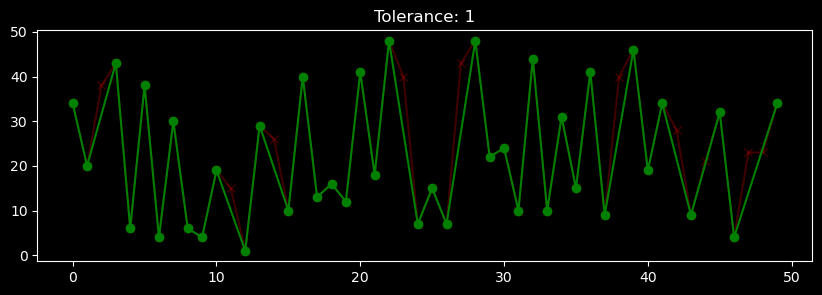

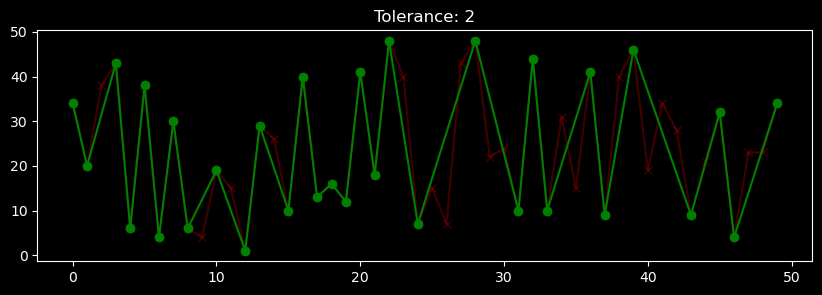

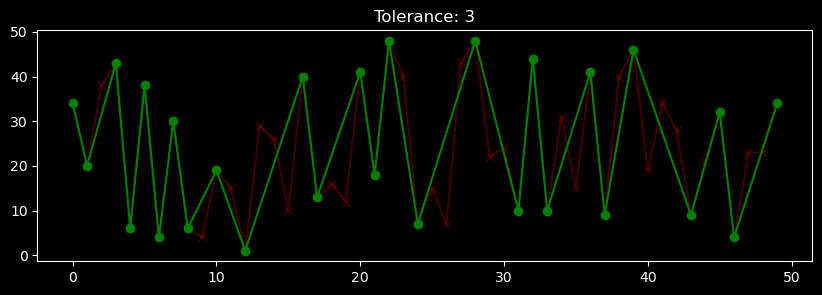

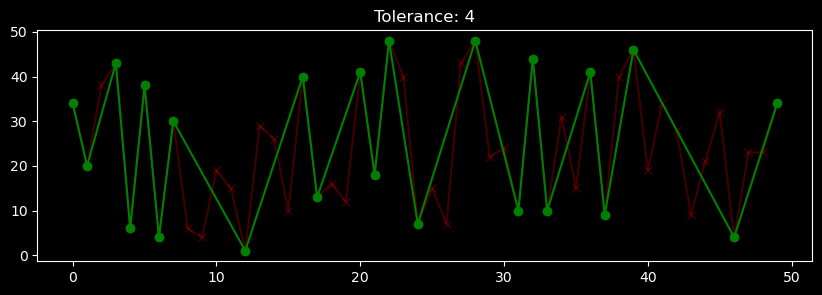

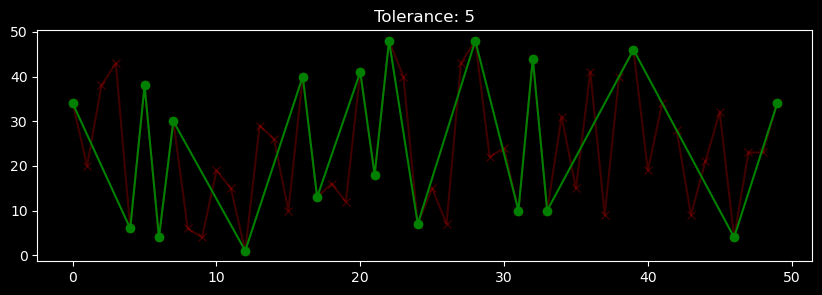

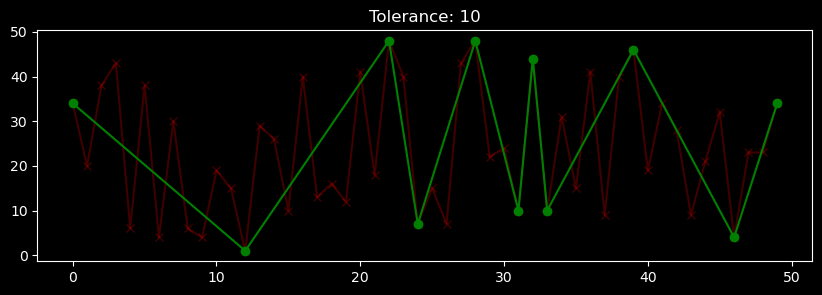

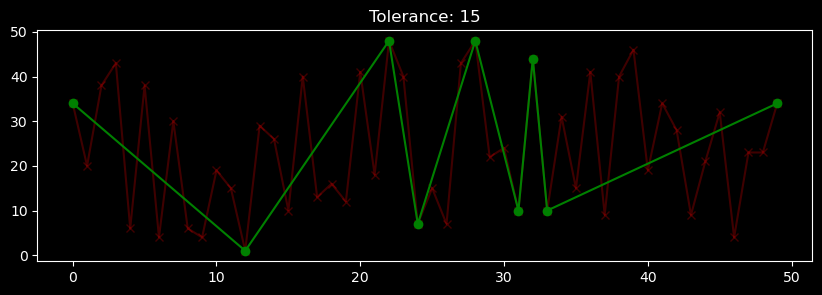

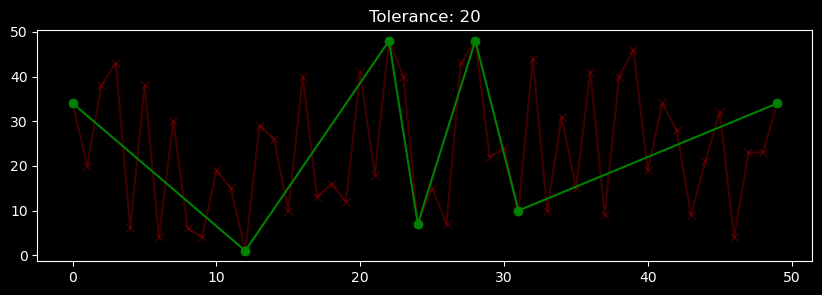

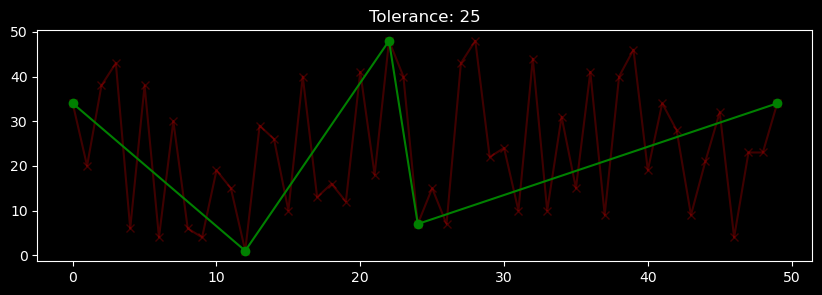

In [107]:
n = 50
tols = [0.5, 1, 2, 3, 4, 5, 10, 15, 20, 25]

l1 = list(zip(list(range(n)), np.random.randint(0, 50, n).tolist()))
x, y = zip(*l1)


for tol in tols:
    xx, yy = zip(*rdp(l1, tol))
    plt.figure(figsize=(10, 3))
    plt.plot(x, y, c='red', alpha=0.25, marker='x')
    plt.plot(xx, yy, c='green', marker='o')
    plt.title(f"Tolerance: {tol}")
    plt.show()


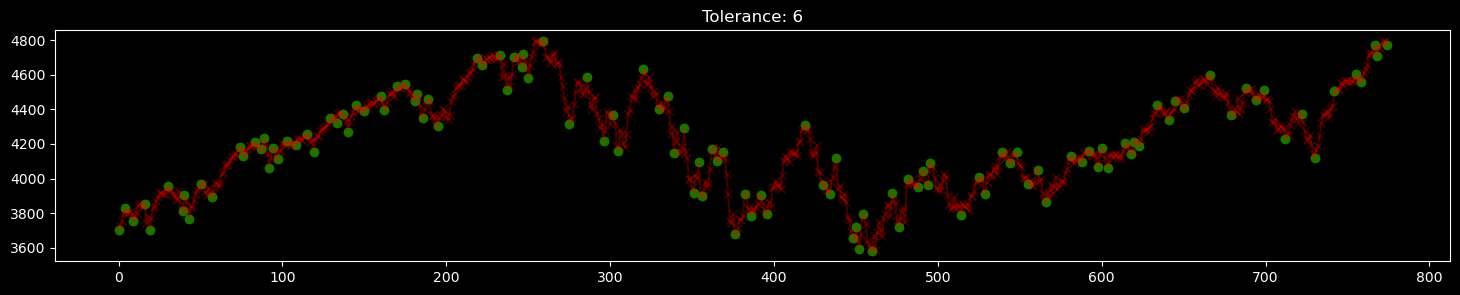

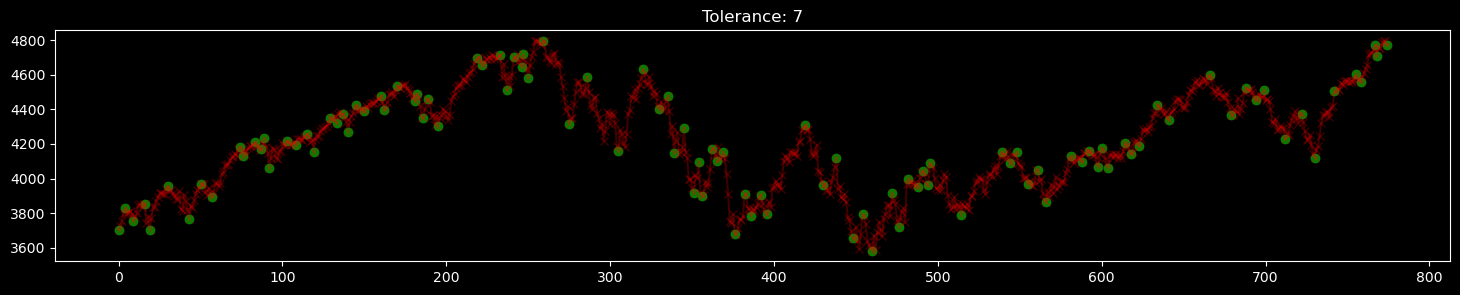

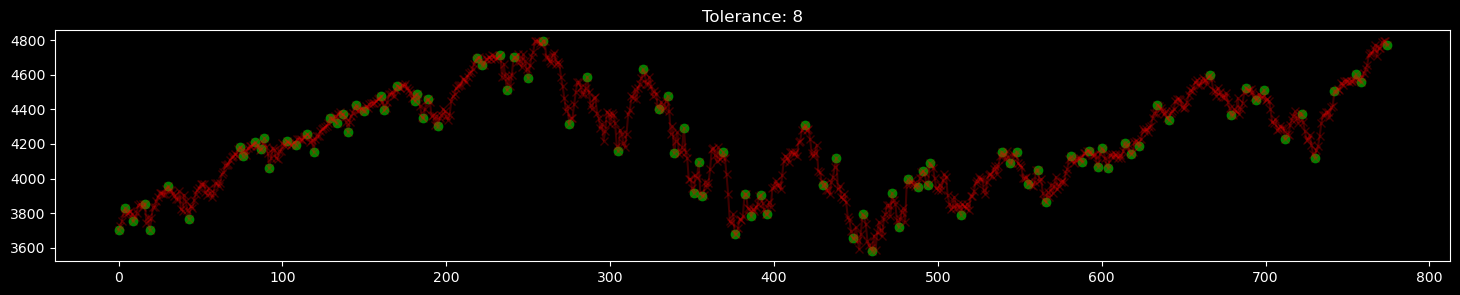

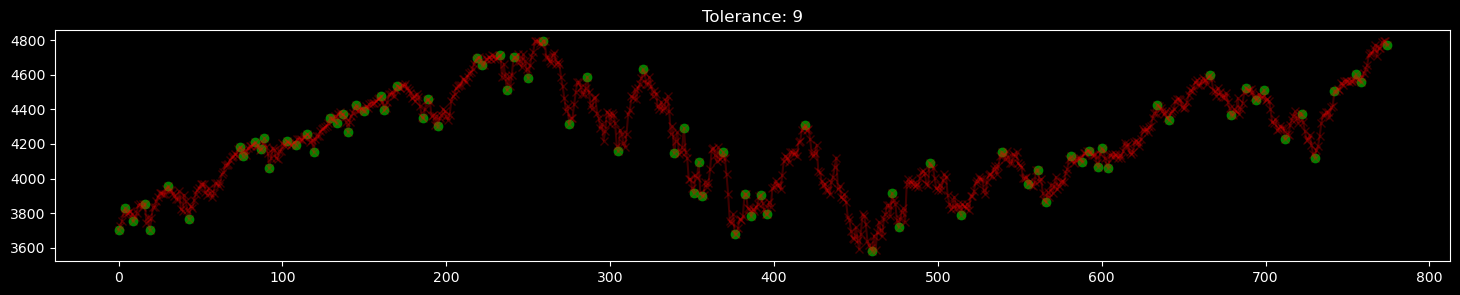

In [154]:
n = 50
# tols = [0.5, 1, 2, 3, 4, 5, 10, 15, 20, 25]
tols = range(6,10)

df_range = df.loc['2021-01-01':'2023-12-31','c']
l1 = list(zip(range(df_range.shape[0]),df_range.values.tolist()))
x, y = zip(*l1)

for tol in tols:
    xx, yy = zip(*rdp(l1, tol))
    plt.figure(figsize=(18, 3))
    plt.plot(xx, yy, c='green', marker='o', linewidth=0)
    plt.plot(x, y, c='red', alpha=0.25, marker='x')
    plt.title(f"Tolerance: {tol}")
    # plt.legend()
    plt.show()


## Use Legacy Data API

In [17]:
from bokeh.plotting import output_notebook

from myquantlab.dataAPI_legacy import AxitraderAPI
from myquantlab.ohlc import candlestick_plot

In [9]:
axi = AxitraderAPI()
axi.info()

======================================== Key Instance Attributes ========================================
source: .......... axitrader
drive: ........... project
raw_data ......... /home/vtec/projects/algot/myquantlab/data/raw-data/axitrader-mt4
datasets Folder .. /home/vtec/projects/algot/myquantlab/data/datasets/axitrader-mt4
data_format ...... mt4
timeframes ....... ['M', 'W', 'D', 'H1', 'M30', 'M15', 'M5', 'M1']
======================================== Other Information ========================================
No API key for axitrader
Ticker lists and respective number of tickers:
  - ticker_list['forex'] has 28 tickers
  - ticker_list['index'] has 10 tickers
  - ticker_list['commodities'] has 4 tickers
  - ticker_list['index futures'] has 10 tickers
  - ticker_list['commodities futures'] has 9 tickers
  - ticker_list['active'] has 61 tickers
Not currently implemented for Axitrader
Date of last file downloaded: 1900-01-01


In [18]:
output_notebook()

Loading BokehJS ...

In [19]:
df = axi.get_dataset(ticker='US500', tf='D')
candlestick_plot(df)

# Next Section